In [3]:
import seaborn as sns 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import os 

from dotenv import load_dotenv

load_dotenv()
%env
os.chdir(os.environ.get("DATASET_PATH"))

In [4]:

tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


our goal is to predict the tip based on another data   
`dependent variables ` - total_bill , sex ,smoker , day , time  
`independent variable` - tip  

In [7]:
# EDA 
tips.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [52]:
from sklearn.preprocessing import StandardScaler , OneHotEncoder
from sklearn.model_selection import train_test_split

X , y = tips.drop(columns='tip') , tips['tip']

X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2, random_state=1)

In [67]:
scale = StandardScaler()
scale_data = pd.DataFrame(scale.fit_transform(tips[['tip','total_bill']]),columns=['tip','total_bill'])
scale_data.describe()

,tip,total_bill
count,2.440000e+02,2.440000e+02
mean,2.839259e-16,-7.871663e-17
std,1.002056e+00,1.002056e+00
min,-1.447189e+00,-1.881547e+00
25%,-7.229713e-01,-7.247111e-01
50%,-7.117518e-02,-2.241005e-01
75%,4.086192e-01,4.886857e-01
max,5.070772e+00,3.492068e+00


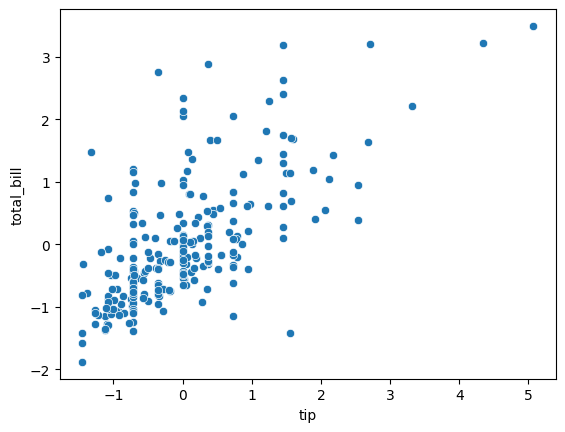

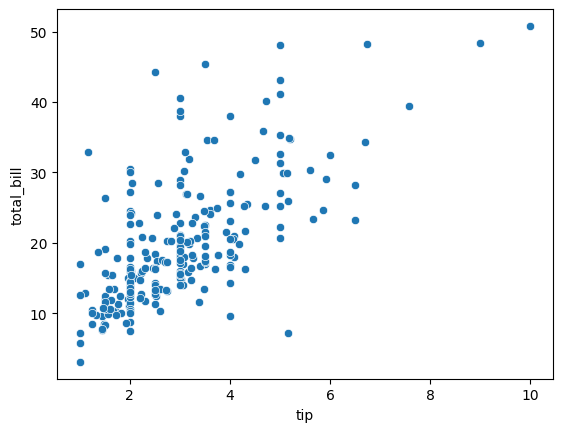

In [66]:
sns.scatterplot(data=scale_data, x='tip', y = 'total_bill')
plt.show()
sns.scatterplot(data=tips, x='tip', y = 'total_bill')
plt.show()

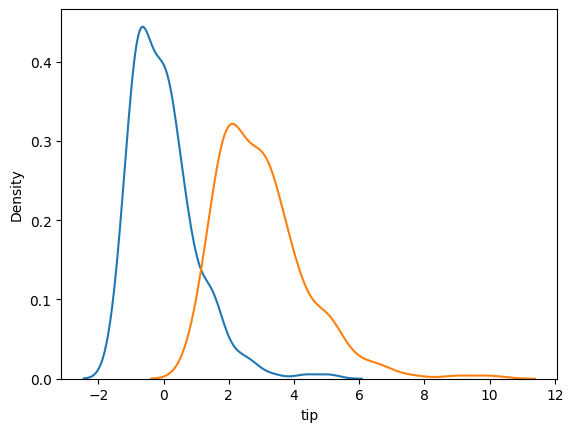

In [69]:
sns.kdeplot(data=scale_data, x='tip')
sns.kdeplot(data=tips, x='tip')
plt.show()

# train linear model after encoding data 


In [34]:
# first of all we will encode the data 
# from sklearn.compose import ColumnTransformer
# ct = ColumnTransformer(transformers=[('ohe',OneHotEncoder(drop='first'),['sex','smoker','day','time'])])
# ct.fit_transform(X_train)


In [35]:
ohe = OneHotEncoder(drop='first',dtype=int, sparse_output=False).set_output(transform='pandas')
X_train_new = ohe.fit_transform(X_train[['day','sex','smoker','time']])
X_train_new = pd.concat([X_train_new,X_train[['total_bill','size']]],axis=1)
X_train_new

,day_Sat,day_Sun,day_Thur,sex_Male,smoker_Yes,time_Lunch,total_bill,size
0,0,1,0,0,0,0,16.99,2
154,0,1,0,1,0,0,19.77,4
167,0,1,0,1,0,0,31.71,4
110,1,0,0,1,0,0,14.00,2
225,0,0,0,0,1,1,16.27,2
...,...,...,...,...,...,...,...,...
137,0,0,1,0,0,1,14.15,2
72,1,0,0,0,1,0,26.86,2
140,0,0,1,0,0,1,17.47,2
235,1,0,0,1,0,0,10.07,2


In [43]:
X_test_new = ohe.fit_transform(X_test[['day','sex','smoker','time']])
X_test_new = pd.concat([X_test_new,X_test[['total_bill','size']]],axis=1)
# X_test_new

In [33]:
X_train_new.isnull().sum()

day_Fri        0
day_Sat        0
day_Sun        0
day_Thur       0
sex_Female     0
sex_Male       0
smoker_No      0
smoker_Yes     0
time_Dinner    0
time_Lunch     0
total_bill     0
size           0
dtype: int64

In [40]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_new,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [47]:
y_pred = lr.predict(X_test_new)

In [48]:
from sklearn.metrics import r2_score
print(r2_score(y_test,y_pred))

0.4875817254349357
